# EDA — FunPang/medical_dataset

Checks the raw CSVs and the processed `dataset.jsonl` (built by `load_data.py`) for missing values, duplicates, and general shape, before we build the embedding/retrieval pipeline on top of it.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAW_DIR = Path("data/raw")
PROCESSED_FILE = Path("data/processed/dataset.jsonl")

DATASET_FILES = [
    "prepared_generated_data_for_nhs_uk_qa_1.csv",
    "prepared_generated_data_for_nhs_uk_conversations_1.csv",
    "prepared_generated_data_for_medical_tasks_1.csv",
    "mental_health_conversation.csv",
]

## 1. Raw CSVs — missing values & duplicates

This is the data *before* `load_data.py` parses it.

In [2]:
for filename in DATASET_FILES:
    df = pd.read_csv(RAW_DIR / filename)
    print(f"--- {filename} ---")
    print(f"rows: {len(df)}")
    print("missing values per column:")
    print(df.isna().sum().to_string())
    print(f"duplicate rows (full row): {df.duplicated().sum()}")
    print(f"duplicate 'text' values: {df['text'].duplicated().sum()}")
    print()

--- prepared_generated_data_for_nhs_uk_qa_1.csv ---
rows: 24665
missing values per column:
Unnamed: 0     0
text           0
raw_data_id    0
duplicate rows (full row): 0
duplicate 'text' values: 0

--- prepared_generated_data_for_nhs_uk_conversations_1.csv ---
rows: 2354
missing values per column:
Unnamed: 0     0
text           0
raw_data_id    0
duplicate rows (full row): 0
duplicate 'text' values: 0

--- prepared_generated_data_for_medical_tasks_1.csv ---
rows: 4689
missing values per column:
Unnamed: 0     0
text           0
raw_data_id    0
duplicate rows (full row): 0
duplicate 'text' values: 0

--- mental_health_conversation.csv ---
rows: 172
missing values per column:
Unnamed: 0     0
text           0
raw_data_id    0
duplicate rows (full row): 0
duplicate 'text' values: 0



## 2. Processed dataset — missing values & duplicates

This is `data/processed/dataset.jsonl`, one row per parsed question/answer pair.

In [3]:
records = [json.loads(line) for line in PROCESSED_FILE.open(encoding="utf-8")]
processed_df = pd.DataFrame(records)
print(f"total records: {len(processed_df)}")
processed_df.head()

total records: 41760


,id,source,question,answer,references
0,prepared_generated_data_for_nhs_uk_qa_1-0-0,prepared_generated_data_for_nhs_uk_qa_1,What is high blood pressure?,High blood pressure is a condition where the f...,[https://www.nhs.uk/conditions/Blood-pressure-...
1,prepared_generated_data_for_nhs_uk_qa_1-1-0,prepared_generated_data_for_nhs_uk_qa_1,What are the risks of high blood pressure?,Persistent high blood pressure can put extra s...,[https://www.nhs.uk/conditions/Blood-pressure-...
2,prepared_generated_data_for_nhs_uk_qa_1-2-0,prepared_generated_data_for_nhs_uk_qa_1,How is high blood pressure diagnosed?,The only way of knowing whether you have high ...,[https://www.nhs.uk/conditions/Blood-pressure-...
3,prepared_generated_data_for_nhs_uk_qa_1-3-0,prepared_generated_data_for_nhs_uk_qa_1,What are the lifestyle changes that can help r...,Lifestyle changes that can help prevent and lo...,[https://www.nhs.uk/conditions/Blood-pressure-...
4,prepared_generated_data_for_nhs_uk_qa_1-4-0,prepared_generated_data_for_nhs_uk_qa_1,What are the medicines used to control high bl...,Common blood pressure medicines include ACE in...,[https://www.nhs.uk/conditions/Blood-pressure-...


In [4]:
print("missing values per column:")
print(processed_df.isna().sum().to_string())
print()
print("empty-string questions:", (processed_df["question"].str.strip() == "").sum())
print("empty-string answers:", (processed_df["answer"].str.strip() == "").sum())
print()
print("exact duplicate (question, answer) pairs:", processed_df.duplicated(subset=["question", "answer"]).sum())
print("duplicate ids:", processed_df["id"].duplicated().sum())

missing values per column:
id            0
source        0
question      0
answer        0
references    0



empty-string questions: 0
empty-string answers: 0

exact duplicate (question, answer) pairs: 20
duplicate ids: 0


`load_data.py` already drops turns with an empty question or answer, so we don't expect blanks here — this cell is a sanity check that the parsing actually did that. Duplicate (question, answer) pairs and NaNs are **not** currently deduplicated/handled — see findings below.

## 3. Question / answer length distribution

In [5]:
processed_df["question_len"] = processed_df["question"].str.split().str.len()
processed_df["answer_len"] = processed_df["answer"].str.split().str.len()
processed_df[["question_len", "answer_len"]].describe()

,question_len,answer_len
count,41760.000000,41760.000000
mean,12.317337,51.668127
std,11.514084,36.646720
min,1.000000,1.000000
25%,7.000000,30.000000
50%,10.000000,43.000000
75%,14.000000,60.000000
max,272.000000,412.000000


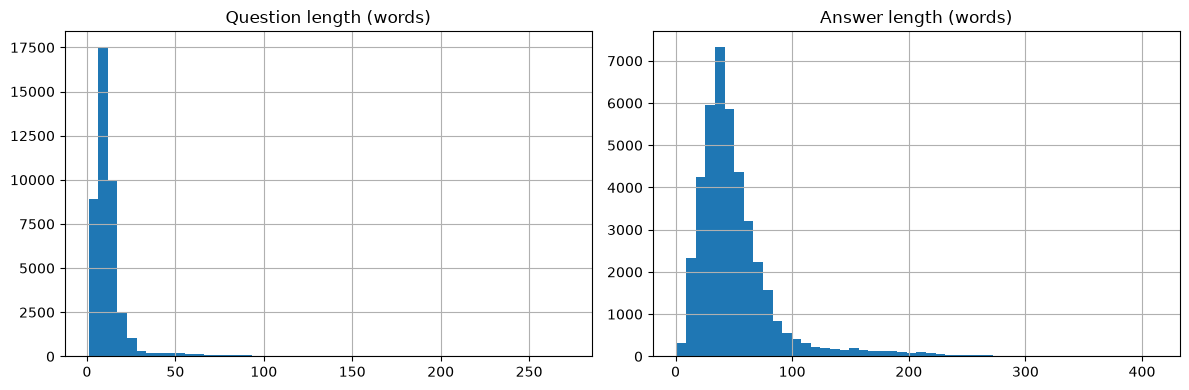

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
processed_df["question_len"].hist(bins=50, ax=axes[0])
axes[0].set_title("Question length (words)")
processed_df["answer_len"].hist(bins=50, ax=axes[1])
axes[1].set_title("Answer length (words)")
plt.tight_layout()
plt.show()

## 4. Records with vs. without a citation

In [7]:
processed_df["has_reference"] = processed_df["references"].apply(lambda r: len(r) > 0)
processed_df.groupby("source")["has_reference"].value_counts().unstack(fill_value=0)

has_reference,True,False
source,,
mental_health_conversation,0,172
prepared_generated_data_for_medical_tasks_1,0,4689
prepared_generated_data_for_nhs_uk_conversations_1,12234,0
prepared_generated_data_for_nhs_uk_qa_1,24665,0


## Findings

Fill this in after running the cells above — in particular:
- Does the raw `text` column have any missing rows, and does that match how many records each source produced in `load_data.py`'s printed counts?
- How many duplicate (question, answer) pairs exist? If it's non-trivial, add a dedup step to `load_data.py`.
- Are there extreme outliers in answer length (e.g. one-word answers, or answers so long they'll need chunking before embedding)?